<a href="https://colab.research.google.com/github/jasonherz41/nba_Jason/blob/main/NBA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
nba_df = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/NBA%202024_25%20Data/nba_2024_25_player_stats.csv")

In [5]:
nba_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PLAYER_NAME           456 non-null    object 
 1   TEAM_ABBREVIATION     456 non-null    object 
 2   AGE                   456 non-null    float64
 3   GP                    456 non-null    int64  
 4   MIN                   456 non-null    float64
 5   PTS                   456 non-null    float64
 6   REB                   456 non-null    float64
 7   AST                   456 non-null    float64
 8   STL                   456 non-null    float64
 9   BLK                   456 non-null    float64
 10  TOV                   456 non-null    float64
 11  FG_PCT                456 non-null    float64
 12  FG3_PCT               456 non-null    float64
 13  FT_PCT                456 non-null    float64
 14  PLUS_MINUS            456 non-null    float64
 15  PLAYER_HEIGHT_INCHES  4

In [6]:
nba_df.isnull().sum() #found missing data

,0
PLAYER_NAME,0
TEAM_ABBREVIATION,0
AGE,0
GP,0
MIN,0
PTS,0
REB,0
AST,0
STL,0
BLK,0


In [7]:
nba_df.loc[nba_df["PLAYER_WEIGHT"].isnull()]
#found the missing weight data

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER
208,Jaylen Wells,MEM,21.0,79,25.9,10.4,3.4,1.7,0.6,0.1,0.9,0.425,0.352,0.822,2.4,80,NaN,2024,2,39


In [8]:
nba_df.loc[nba_df["PLAYER_NAME"] == "Jaylen Wells", "PLAYER_WEIGHT"] = 206.0
nba_df.loc[nba_df["PLAYER_NAME"] == "Jaylen Wells", ["PLAYER_NAME", "PLAYER_WEIGHT"]]
#filled the missing weight data

,PLAYER_NAME,PLAYER_WEIGHT
208,Jaylen Wells,206.0


In [9]:
nba_df.loc[nba_df["DRAFT_ROUND"].isnull()]
nba_df.loc[nba_df["DRAFT_NUMBER"].isnull()]
#found the missing draft data

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER
158,Haywood Highsmith,MIA,28.0,74,24.6,6.5,3.4,1.5,0.9,0.5,0.7,0.458,0.382,0.721,0.8,77,220.0,2018,NaN,NaN
404,T.J. McConnell,IND,33.0,79,17.9,9.1,2.4,4.4,1.1,0.3,1.4,0.519,0.306,0.740,-0.7,73,190.0,2015,0,NaN


In [10]:
nba_df.loc[nba_df["PLAYER_NAME"] == "Haywood Highsmith", "DRAFT_ROUND"] = "Undrafted"
nba_df.loc[nba_df["PLAYER_NAME"] == "Haywood Highsmith", "DRAFT_NUMBER"] = "Undrafted"
nba_df.loc[nba_df["PLAYER_NAME"] == "T.J. McConnell", "DRAFT_ROUND"] = "Undrafted"
nba_df.loc[nba_df["PLAYER_NAME"] == "T.J. McConnell", "DRAFT_NUMBER"] = "Undrafted"

nba_df.loc[nba_df["PLAYER_NAME"].isin(["Haywood Highsmith", "T.J. McConnell"]),["PLAYER_NAME", "DRAFT_ROUND", "DRAFT_NUMBER"]]
#filled the missing draft data

,PLAYER_NAME,DRAFT_ROUND,DRAFT_NUMBER
158,Haywood Highsmith,Undrafted,Undrafted
404,T.J. McConnell,Undrafted,Undrafted


In [11]:
!pip install matplotlib
import matplotlib.pyplot as plt

!pip install pandas
import pandas as pd

!pip install numpy
import numpy as np

!pip install seaborn
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [12]:
team_df = pd.DataFrame({"TEAM_ABBREVIATION": ["ATL", "BOS", "BKN", "CHA", "CHI", "CLE", "DAL", "DEN", "DET", "GSW",
        "HOU", "IND", "LAC", "LAL", "MEM", "MIA", "MIL", "MIN", "NOP", "NYK",
        "OKC", "ORL", "PHI", "PHX", "POR", "SAC", "SAS", "TOR", "UTA", "WAS"],
        "WINS": [40, 61, 26, 19, 39, 64, 39, 50, 44, 48, 52, 50, 50, 50, 48, 37, 48, 49, 21, 51, 68, 41, 24, 36, 36, 40, 34, 30, 17, 18],
        "LOSSES": [42, 21, 56, 63, 43, 18, 43, 32, 38, 34, 30, 32, 32, 32, 34, 45, 34, 33, 61, 31, 14, 41, 58, 46, 46, 42, 38, 52, 65, 64],
        "TEAM_POINT_DIFF": [-3.4, 9.1, -5.1, -9.3, -6.2, 9.5, 2.4, 3.8, 1.9, 3.3, 4.0, -1.5, 2.1, -1.5, -1.3, 2.6, 1.8, 5.1, -9.5, 4.1, 12.9, 5.2, -2.1, 1.5, -8.5, 2.3, -1.2, -5.9, -6.7, -12.3]})
#created data set with new information

In [14]:
team_df["WIN_PCT"] = team_df["WINS"]/82
team_df.head()

,TEAM_ABBREVIATION,WINS,LOSSES,TEAM_POINT_DIFF,WIN_PCT
0,ATL,40,42,-3.4,0.487805
1,BOS,61,21,9.1,0.743902
2,BKN,26,56,-5.1,0.317073
3,CHA,19,63,-9.3,0.231707
4,CHI,39,43,-6.2,0.475610


In [15]:
nba_df = nba_df.merge(team_df, on = "TEAM_ABBREVIATION", how="left")
nba_df.head()
# merged my two data sets

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,...,PLUS_MINUS,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER,WINS,LOSSES,TEAM_POINT_DIFF,WIN_PCT
0,A.J. Lawson,TOR,24.0,26,18.7,9.1,3.3,1.2,0.5,0.2,...,-0.7,78,179.0,Undrafted,Undrafted,Undrafted,30,52,-5.9,0.365854
1,AJ Green,MIL,25.0,73,22.7,7.4,2.4,1.5,0.5,0.1,...,3.1,76,190.0,Undrafted,Undrafted,Undrafted,48,34,1.8,0.585366
2,AJ Johnson,WAS,20.0,29,22.0,7.6,2.0,2.6,0.4,0.1,...,-5.2,77,160.0,2024,1,23,18,64,-12.3,0.219512
3,Aaron Gordon,DEN,29.0,51,28.4,14.7,4.8,3.2,0.5,0.3,...,5.9,80,235.0,2014,1,4,50,32,3.8,0.609756
4,Aaron Holiday,HOU,28.0,62,12.8,5.5,1.3,1.3,0.3,0.2,...,1.4,72,185.0,2018,1,23,52,30,4.0,0.634146


In [17]:
nba_df["ADJ_PLUS_MINUS"]= nba_df["PLUS_MINUS"] - nba_df["TEAM_POINT_DIFF"]
nba_df.head()
# this is more important plus/minus

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,...,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER,WINS,LOSSES,TEAM_POINT_DIFF,WIN_PCT,ADJ_PLUS_MINUS
0,A.J. Lawson,TOR,24.0,26,18.7,9.1,3.3,1.2,0.5,0.2,...,78,179.0,Undrafted,Undrafted,Undrafted,30,52,-5.9,0.365854,5.2
1,AJ Green,MIL,25.0,73,22.7,7.4,2.4,1.5,0.5,0.1,...,76,190.0,Undrafted,Undrafted,Undrafted,48,34,1.8,0.585366,1.3
2,AJ Johnson,WAS,20.0,29,22.0,7.6,2.0,2.6,0.4,0.1,...,77,160.0,2024,1,23,18,64,-12.3,0.219512,7.1
3,Aaron Gordon,DEN,29.0,51,28.4,14.7,4.8,3.2,0.5,0.3,...,80,235.0,2014,1,4,50,32,3.8,0.609756,2.1
4,Aaron Holiday,HOU,28.0,62,12.8,5.5,1.3,1.3,0.3,0.2,...,72,185.0,2018,1,23,52,30,4.0,0.634146,-2.6


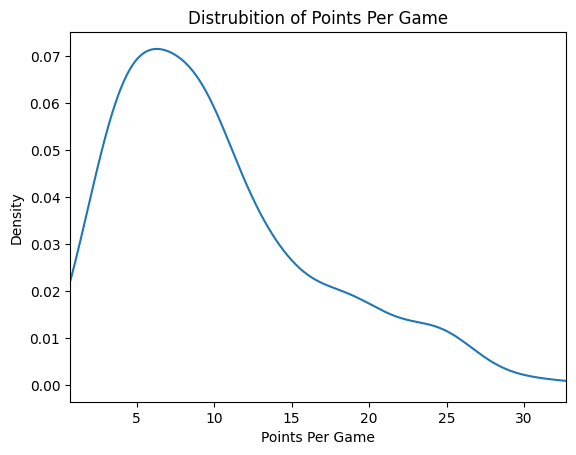

In [18]:
nba_df["PTS"].plot(kind = "density")

plt.title("Distrubition of Points Per Game")
plt.xlabel("Points Per Game")
plt.xlim(nba_df["PTS"].min(), nba_df["PTS"].max())
plt.show()

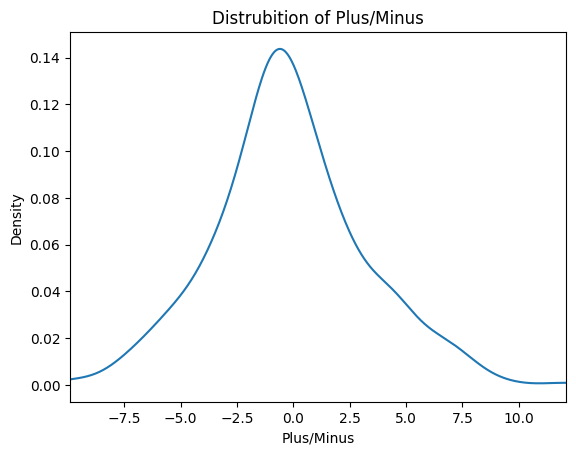

In [19]:
nba_df["PLUS_MINUS"].plot(kind = "density")

plt.title("Distrubition of Plus/Minus")
plt.xlabel("Plus/Minus")
plt.xlim(nba_df["PLUS_MINUS"].min(), nba_df["PLUS_MINUS"].max())
plt.show()

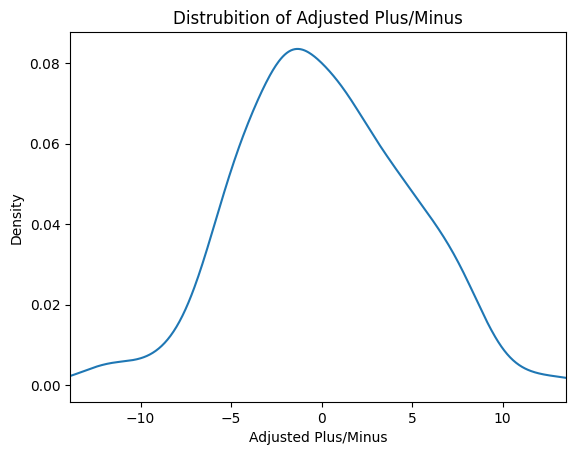

In [20]:
nba_df["ADJ_PLUS_MINUS"].plot(kind = "density")

plt.title("Distrubition of Adjusted Plus/Minus")
plt.xlabel("Adjusted Plus/Minus")
plt.xlim(nba_df["ADJ_PLUS_MINUS"].min(), nba_df["ADJ_PLUS_MINUS"].max())
plt.show()

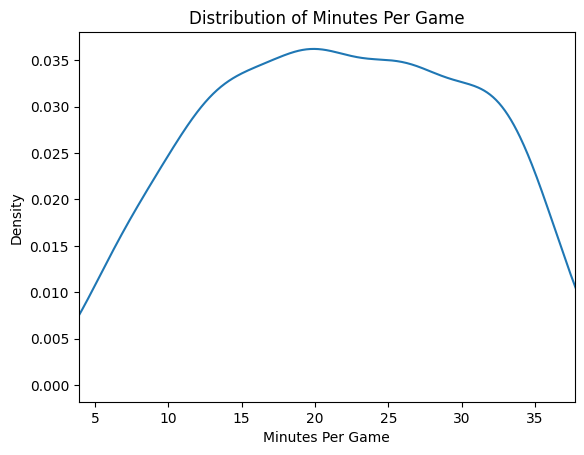

In [21]:
nba_df["MIN"].plot(kind="density")

plt.title("Distribution of Minutes Per Game")
plt.xlabel("Minutes Per Game")
plt.xlim(nba_df["MIN"].min(), nba_df["MIN"].max())
plt.show()

In [22]:
nba_df.sort_values("PTS", ascending=False)[["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "MIN", "PLUS_MINUS"]].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,MIN,PLUS_MINUS
393,Shai Gilgeous-Alexander,OKC,32.7,34.2,12.1
151,Giannis Antetokounmpo,MIL,30.4,34.2,5.0
338,Nikola Jokić,DEN,29.6,36.7,8.5
296,Luka Dončić,LAL,28.2,35.4,6.9
26,Anthony Edwards,MIN,27.6,36.3,3.7
211,Jayson Tatum,BOS,26.8,36.4,7.4
269,Kevin Durant,PHX,26.6,36.5,-0.6
437,Tyrese Maxey,PHI,26.3,37.7,-2.4
59,Cade Cunningham,DET,26.1,35.0,2.5
183,Jalen Brunson,NYK,26.0,35.4,2.2


In [23]:
nba_df.sort_values("PTS", ascending=True)[["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "MIN", "PLUS_MINUS"]].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,MIN,PLUS_MINUS
399,Stanley Umude,MIL,0.7,3.9,-0.7
446,Xavier Tillman,BOS,1.0,7.0,-0.4
398,Spencer Jones,DEN,1.3,6.2,-2.3
424,Trey Alexander,DEN,1.3,4.9,-1.0
73,Chris Livingston,MIL,1.4,5.0,-1.4
395,Sidy Cissoko,POR,1.5,5.2,0.4
14,Alex Len,LAL,1.6,8.3,-3.3
237,Jordan Walsh,BOS,1.6,7.8,0.5
447,Yuki Kawamura,MEM,1.6,4.2,1.2
13,Alex Ducas,OKC,1.7,6.0,-1.0


In [24]:
nba_df.sort_values("PLUS_MINUS", ascending=False)[["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "REB", "AST", "PLUS_MINUS"]].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST,PLUS_MINUS
393,Shai Gilgeous-Alexander,OKC,32.7,5.0,6.4,12.1
71,Chet Holmgren,OKC,15.0,8.0,2.0,9.2
338,Nikola Jokić,DEN,29.6,12.7,10.2,8.5
257,Kawhi Leonard,LAC,21.5,5.9,3.1,8.0
140,Evan Mobley,CLE,18.5,9.3,3.2,7.7
295,Luguentz Dort,OKC,10.1,4.1,1.6,7.7
211,Jayson Tatum,BOS,26.8,8.7,6.0,7.4
126,Donovan Mitchell,CLE,24.0,4.5,5.0,7.4
166,Isaiah Joe,OKC,10.2,2.6,1.6,7.4
165,Isaiah Hartenstein,OKC,11.2,10.7,3.8,7.3


In [25]:
nba_df.sort_values("PLUS_MINUS", ascending=True)[["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "REB", "AST", "PLUS_MINUS"]].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST,PLUS_MINUS
38,Bilal Coulibaly,WAS,12.3,5.0,3.4,-9.9
56,Bub Carrington,WAS,9.8,4.2,4.4,-9.7
236,Jordan Poole,WAS,20.5,3.0,4.5,-8.2
15,Alex Sarr,WAS,13.0,6.5,2.4,-8.1
253,KJ Simpson,CHA,7.8,3.0,3.1,-7.7
274,Keyonte George,UTA,16.8,3.8,5.6,-7.6
427,Trey Murphy III,NOP,21.2,5.1,3.5,-7.2
333,Nic Claxton,BKN,10.3,7.4,2.2,-7.1
293,Lonnie Walker IV,PHI,12.4,3.2,2.5,-7.1
448,Yves Missi,NOP,9.1,8.2,1.4,-7.0


In [26]:
nba_df.sort_values("REB", ascending=False)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "REB", "PTS", "PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,REB,PTS,PLUS_MINUS
123,Domantas Sabonis,SAC,13.9,19.1,2.1
255,Karl-Anthony Towns,NYK,12.8,24.4,5.3
338,Nikola Jokić,DEN,12.7,29.6,8.5
169,Ivica Zubac,LAC,12.6,16.8,6.4
443,Walker Kessler,UTA,12.2,11.1,-5.7
151,Giannis Antetokounmpo,MIL,11.9,30.4,5.0
25,Anthony Davis,DAL,11.6,24.7,0.5
440,Victor Wembanyama,SAS,11.0,24.3,2.2
379,Rudy Gobert,MIN,10.9,12.0,4.5
165,Isaiah Hartenstein,OKC,10.7,11.2,7.3


In [27]:
nba_df.sort_values("AST", ascending=False)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "AST", "PTS", "PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,AST,PTS,PLUS_MINUS
419,Trae Young,ATL,11.6,24.2,0.4
338,Nikola Jokić,DEN,10.2,29.6,8.5
435,Tyrese Haliburton,IND,9.2,18.6,3.0
59,Cade Cunningham,DET,9.1,26.1,2.5
195,James Harden,LAC,8.7,22.8,4.4
291,LeBron James,LAL,8.2,24.4,-0.8
296,Luka Dončić,LAL,7.7,28.2,6.9
74,Chris Paul,SAS,7.4,8.8,0.0
110,Dejounte Murray,NOP,7.4,17.5,-6.7
287,LaMelo Ball,CHA,7.4,25.2,-2.8


In [28]:
nba_df.sort_values("STL", ascending=False)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "STL", "PTS", "PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,STL,PTS,PLUS_MINUS
136,Dyson Daniels,ATL,3.0,14.1,-0.9
110,Dejounte Murray,NOP,2.0,17.5,-6.7
159,Herbert Jones,NOP,1.9,10.3,-1.0
338,Nikola Jokić,DEN,1.8,29.6,8.5
359,Paul George,PHI,1.8,16.2,-2.0
69,Cason Wallace,OKC,1.8,8.4,5.4
437,Tyrese Maxey,PHI,1.8,26.3,-2.4
296,Luka Dončić,LAL,1.8,28.2,6.9
30,Ausar Thompson,DET,1.7,10.1,1.1
393,Shai Gilgeous-Alexander,OKC,1.7,32.7,12.1


In [29]:
nba_df.sort_values("ADJ_PLUS_MINUS", ascending=False)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "REB", "AST", "PLUS_MINUS", "TEAM_POINT_DIFF", "ADJ_PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST,PLUS_MINUS,TEAM_POINT_DIFF,ADJ_PLUS_MINUS
306,Marcus Smart,WAS,9.0,2.1,3.2,1.2,-12.3,13.5
275,Khris Middleton,WAS,11.9,3.7,4.1,1.1,-12.3,13.4
224,Johnny Davis,WAS,2.4,1.1,0.3,-0.8,-12.3,11.5
373,Richaun Holmes,WAS,7.4,5.7,1.4,-1.2,-12.3,11.1
27,Anthony Gill,WAS,2.5,1.3,0.3,-1.4,-12.3,10.9
81,Colby Jones,WAS,4.0,2.2,1.1,-2.9,-12.3,9.4
294,Lonzo Ball,CHI,7.6,3.4,3.3,2.9,-6.2,9.1
168,Isaiah Wong,CHA,6.0,1.6,1.4,-0.3,-9.3,9.0
243,Josh Okogie,CHA,7.1,2.8,0.8,-0.3,-9.3,9.0
395,Sidy Cissoko,POR,1.5,1.0,0.7,0.4,-8.5,8.9


In [30]:
nba_df.sort_values("ADJ_PLUS_MINUS", ascending=True)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "REB", "AST", "PLUS_MINUS", "TEAM_POINT_DIFF", "ADJ_PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST,PLUS_MINUS,TEAM_POINT_DIFF,ADJ_PLUS_MINUS
13,Alex Ducas,OKC,1.7,1.2,0.2,-1.0,12.9,-13.9
7,Adam Flagler,OKC,1.8,0.7,0.3,0.2,12.9,-12.7
203,Javonte Green,CLE,5.1,3.2,0.8,-3.1,9.5,-12.6
350,Ousmane Dieng,OKC,3.8,2.2,0.8,1.2,12.9,-11.7
46,Branden Carlson,OKC,3.8,1.7,0.4,1.3,12.9,-11.6
428,Tristan Thompson,CLE,1.7,3.4,0.6,-2.1,9.5,-11.6
122,Dillon Jones,OKC,2.5,2.2,1.1,1.4,12.9,-11.5
416,Torrey Craig,BOS,4.2,2.8,0.7,-1.9,9.1,-11.0
88,Craig Porter Jr.,CLE,3.7,1.3,1.4,-0.9,9.5,-10.4
446,Xavier Tillman,BOS,1.0,1.3,0.2,-0.4,9.1,-9.5


In [31]:
nba_df["TEAM_ABBREVIATION"].value_counts()

,count
TEAM_ABBREVIATION,
NOP,18
WAS,17
LAL,17
MEM,17
DAL,17
OKC,17
PHX,16
PHI,16
HOU,16


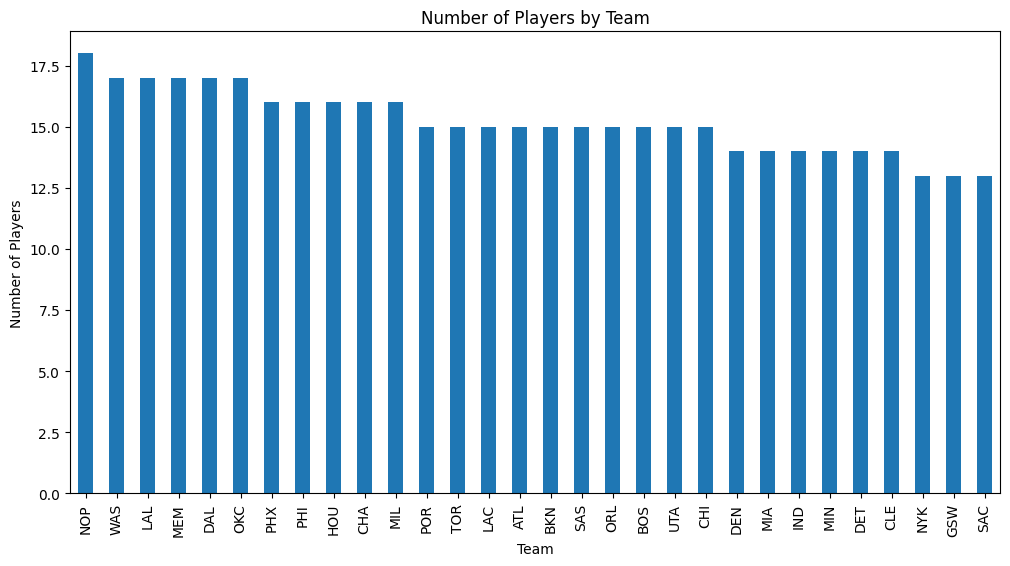

In [32]:
nba_df["TEAM_ABBREVIATION"].value_counts().plot(kind="bar", figsize=(12, 6))

plt.title("Number of Players by Team")
plt.xlabel("Team")
plt.ylabel("Number of Players")
plt.show()

In [33]:
number_data=[
    "AGE", "GP", "MIN", "PTS", "REB", "AST", "STL", "BLK",
    "TOV", "FG_PCT", "FG3_PCT", "FT_PCT", "PLUS_MINUS",
    "ADJ_PLUS_MINUS", "PLAYER_HEIGHT_INCHES", "PLAYER_WEIGHT",
    "WINS", "LOSSES", "WIN_PCT", "TEAM_POINT_DIFF"]
correlation_table = nba_df[number_data].corr()

correlation_table

,AGE,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,ADJ_PLUS_MINUS,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,WINS,LOSSES,WIN_PCT,TEAM_POINT_DIFF
AGE,1.000000,0.051452,0.137388,0.107187,0.071276,0.168801,0.104315,-0.007145,0.048766,0.048716,0.094502,0.112317,0.188167,-0.042848,-0.075116,0.162298,0.099398,-0.097496,0.099398,0.136371
GP,0.051452,1.000000,0.522017,0.380028,0.316091,0.311540,0.331001,0.139428,0.272041,0.180469,0.135348,0.108736,0.242753,-0.023424,0.010476,0.034056,0.160994,-0.168590,0.160994,0.151521
MIN,0.137388,0.522017,1.000000,0.879073,0.622161,0.715873,0.719794,0.341957,0.774734,0.133903,0.192679,0.302965,0.165911,0.172891,0.001165,0.018079,-0.074952,0.075397,-0.074952,-0.041204
PTS,0.107187,0.380028,0.879073,1.000000,0.571518,0.751995,0.615362,0.290388,0.851849,0.144476,0.223765,0.337375,0.231239,0.160701,0.004071,0.026034,-0.026403,0.024284,-0.026403,0.004084
REB,0.071276,0.316091,0.622161,0.571518,1.000000,0.365314,0.387164,0.671298,0.538094,0.505448,-0.225082,-0.088912,0.186328,0.149278,0.542663,0.528286,-0.022503,0.020926,-0.022503,-0.011874
AST,0.168801,0.311540,0.715873,0.751995,0.365314,1.000000,0.647877,0.078879,0.862851,-0.007088,0.164552,0.292613,0.174627,0.153748,-0.267869,-0.165953,-0.028262,0.026222,-0.028262,-0.021738
STL,0.104315,0.331001,0.719794,0.615362,0.387164,0.647877,1.000000,0.214552,0.618567,0.002047,0.204414,0.209332,0.209913,0.152443,-0.192525,-0.160388,-0.013958,0.013788,-0.013958,-0.001322
BLK,-0.007145,0.139428,0.341957,0.290388,0.671298,0.078879,0.214552,1.000000,0.258167,0.466904,-0.260096,-0.144617,0.131600,0.088902,0.576521,0.431225,0.001828,-0.009776,0.001828,0.004281
TOV,0.048766,0.272041,0.774734,0.851849,0.538094,0.862851,0.618567,0.258167,1.000000,0.072257,0.105133,0.216704,0.058088,0.190324,-0.048428,-0.002460,-0.142205,0.140798,-0.142205,-0.113891
FG_PCT,0.048716,0.180469,0.133903,0.144476,0.505448,-0.007088,0.002047,0.466904,0.072257,1.000000,-0.353884,-0.256412,0.192265,0.047735,0.513402,0.496413,0.076485,-0.081500,0.076485,0.069209


In [34]:
correlation_table["PLUS_MINUS"].sort_values(ascending=False)

,PLUS_MINUS
PLUS_MINUS,1.000000
WIN_PCT,0.724161
WINS,0.724161
TEAM_POINT_DIFF,0.650162
GP,0.242753
PTS,0.231239
STL,0.209913
FG_PCT,0.192265
AGE,0.188167
REB,0.186328


In [35]:
correlation_table["ADJ_PLUS_MINUS"].sort_values(ascending=False)

,ADJ_PLUS_MINUS
ADJ_PLUS_MINUS,1.000000
LOSSES,0.602096
TOV,0.190324
MIN,0.172891
PTS,0.160701
AST,0.153748
STL,0.152443
REB,0.149278
BLK,0.088902
FT_PCT,0.071806


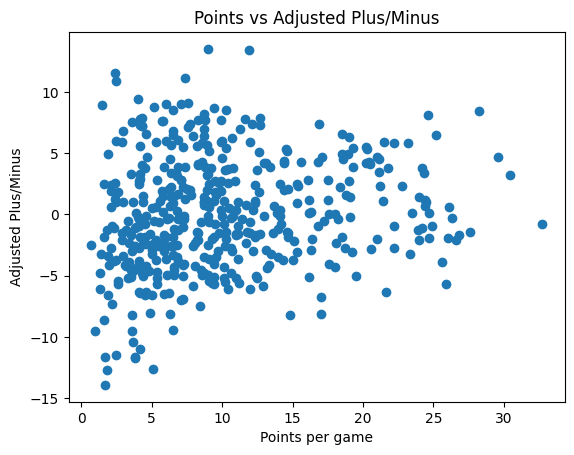

In [36]:
plt.scatter(nba_df["PTS"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Points vs Adjusted Plus/Minus")
plt.xlabel("Points per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

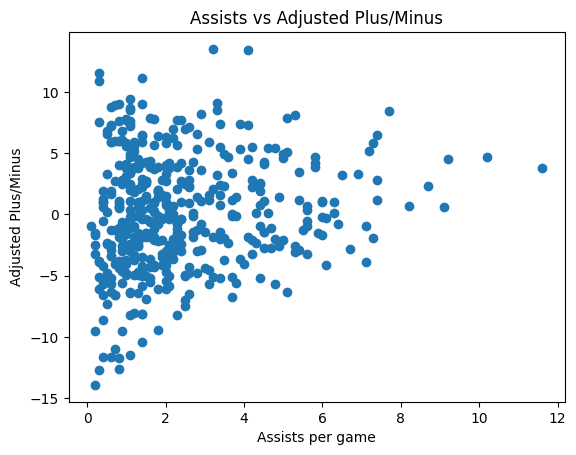

In [37]:
plt.scatter(nba_df["AST"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Assists vs Adjusted Plus/Minus")
plt.xlabel("Assists per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

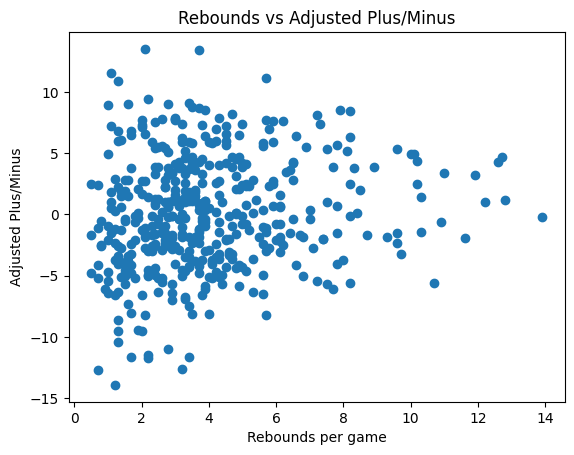

In [38]:
plt.scatter(nba_df["REB"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Rebounds vs Adjusted Plus/Minus")
plt.xlabel("Rebounds per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

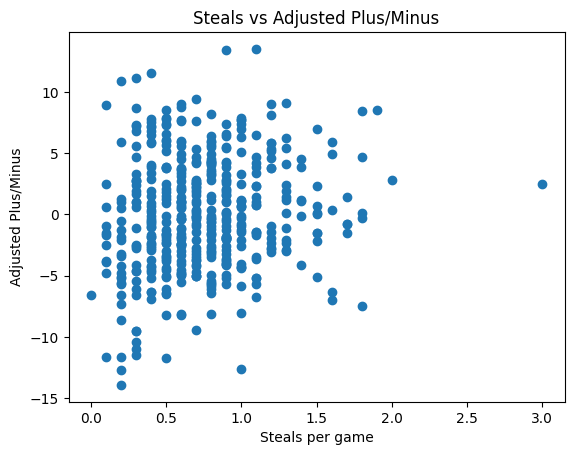

In [39]:
plt.scatter(nba_df["STL"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Steals vs Adjusted Plus/Minus")
plt.xlabel("Steals per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

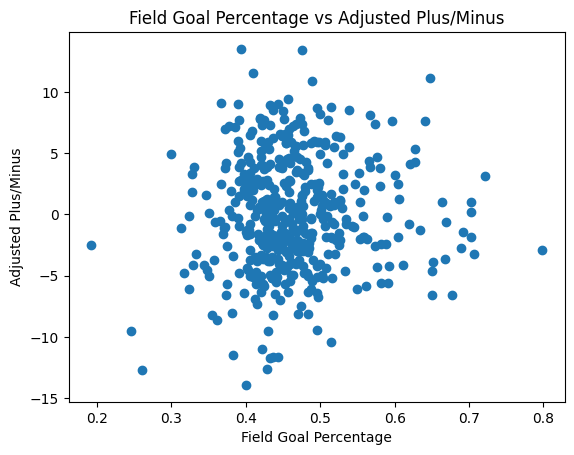

In [40]:
plt.scatter(nba_df["FG_PCT"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Field Goal Percentage vs Adjusted Plus/Minus")
plt.xlabel("Field Goal Percentage")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

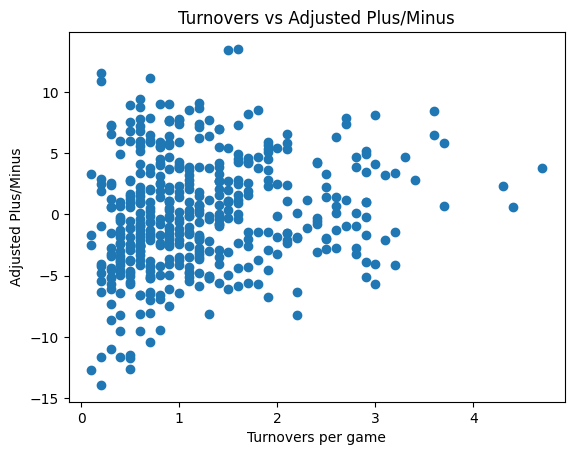

In [41]:
plt.scatter(nba_df["TOV"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Turnovers vs Adjusted Plus/Minus")
plt.xlabel("Turnovers per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

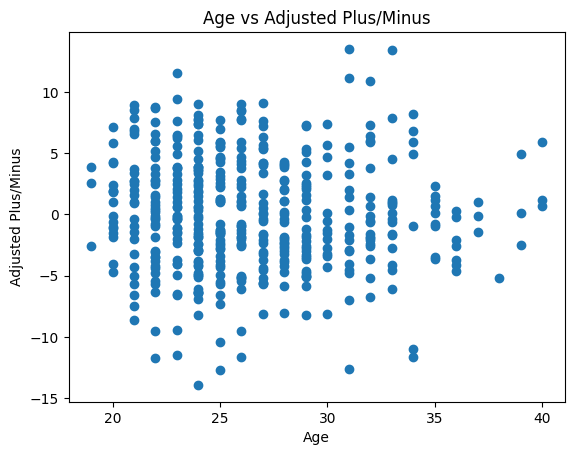

In [43]:
plt.scatter(nba_df["AGE"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Age vs Adjusted Plus/Minus")
plt.xlabel("Age")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

In [51]:
nba_df["PTS_SCALED"]= nba_df["PTS"]/nba_df["PTS"].max()
nba_df["REB_SCALED"]= nba_df["REB"]/nba_df["REB"].max()
nba_df["AST_SCALED"]= nba_df["AST"]/nba_df["AST"].max()
nba_df["STL_SCALED"]= nba_df["STL"]/nba_df["STL"].max()
nba_df["BLK_SCALED"]= nba_df["BLK"]/nba_df["BLK"].max()
nba_df["TOV_SCALED"]= nba_df["TOV"]/nba_df["TOV"].max()
nba_df["MIN_SCALED"]= nba_df["MIN"]/nba_df["MIN"].max()
nba_df["FG_PCT_SCALED"]= nba_df["FG_PCT"]/nba_df["FG_PCT"].max()
nba_df["FG3_PCT_SCALED"]= nba_df["FG3_PCT"]/nba_df["FG3_PCT"].max()
nba_df["ADJ_PM_SCALED"]= (nba_df["ADJ_PLUS_MINUS"] - nba_df["ADJ_PLUS_MINUS"].min())/(nba_df["ADJ_PLUS_MINUS"].max()- nba_df["ADJ_PLUS_MINUS"].min())


In [55]:
nba_df["AGE_VALUE"]= 1 - ((nba_df["AGE"] - nba_df["AGE"].min()) / (nba_df["AGE"].max() - nba_df["AGE"].min()))

In [57]:
nba_df["TRADE_VALUE_SCORE"]= (0.3*nba_df["ADJ_PM_SCALED"]+
                              0.15*nba_df["PTS_SCALED"] +
                              0.1*nba_df["REB_SCALED"] +
                              0.1*nba_df["AST_SCALED"] +
                              0.1*nba_df["STL_SCALED"] +
                              0.1*nba_df["BLK_SCALED"] +
                              0.1*nba_df["FG_PCT_SCALED"] +
                              0.05*nba_df["FG3_PCT_SCALED"] +
                              0.05*nba_df["MIN_SCALED"] +
                              0.3*nba_df["AGE_VALUE"] -
                              0.08*nba_df["TOV_SCALED"])

In [59]:
nba_df.sort_values("TRADE_VALUE_SCORE", ascending = False).head(20)

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,...,AST_SCALED,STL_SCALED,BLK_SCALED,TOV_SCALED,MIN_SCALED,FG_PCT_SCALED,FG3_PCT_SCALED,ADJ_PM_SCALED,AGE_VALUE,TRADE_VALUE_SCORE
440,Victor Wembanyama,SAS,21.0,46,33.2,24.3,11.0,3.7,1.1,3.8,...,0.318966,0.366667,1.000000,0.680851,0.880637,0.596491,0.623009,0.631387,0.904762,0.900376
296,Luka Dončić,LAL,26.0,50,35.4,28.2,8.2,7.7,1.8,0.4,...,0.663793,0.600000,0.105263,0.765957,0.938992,0.563910,0.651327,0.813869,0.666667,0.844047
338,Nikola Jokić,DEN,30.0,70,36.7,29.6,12.7,10.2,1.8,0.6,...,0.879310,0.600000,0.157895,0.702128,0.973475,0.721805,0.738053,0.678832,0.476190,0.838961
455,Zion Williamson,NOP,24.0,30,28.6,24.6,7.2,5.3,1.2,0.9,...,0.456897,0.400000,0.236842,0.638298,0.758621,0.710526,0.408850,0.802920,0.761905,0.821826
186,Jalen Johnson,ATL,23.0,36,35.7,18.9,10.0,5.0,1.6,1.0,...,0.431034,0.533333,0.263158,0.617021,0.946950,0.626566,0.552212,0.686131,0.809524,0.818342
136,Dyson Daniels,ATL,22.0,76,33.8,14.1,5.9,4.4,3.0,0.7,...,0.379310,1.000000,0.184211,0.425532,0.896552,0.617794,0.601770,0.598540,0.857143,0.802835
239,Josh Giddey,CHI,22.0,70,30.2,14.6,8.1,7.2,1.2,0.6,...,0.620690,0.400000,0.157895,0.617021,0.801061,0.582707,0.669027,0.697080,0.857143,0.791785
287,LaMelo Ball,CHA,23.0,47,32.0,25.2,4.9,7.4,1.1,0.3,...,0.637931,0.366667,0.078947,0.765957,0.848806,0.507519,0.600000,0.744526,0.809524,0.787333
435,Tyrese Haliburton,IND,25.0,73,33.6,18.6,3.5,9.2,1.4,0.7,...,0.793103,0.466667,0.184211,0.340426,0.891247,0.592732,0.686726,0.671533,0.714286,0.781582
389,Scottie Barnes,TOR,23.0,65,32.8,19.3,7.7,5.8,1.4,1.0,...,0.500000,0.466667,0.263158,0.595745,0.870027,0.558897,0.479646,0.649635,0.809524,0.780372


In [65]:
underdvalued_targets = nba_df[(nba_df["MIN"]<25) &
                              (nba_df["PTS"]<20) &
                              (nba_df["AGE"]<30) &
                              (nba_df["TRADE_VALUE_SCORE"]>0.7)]
underdvalued_targets.head(20)

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,...,AST_SCALED,STL_SCALED,BLK_SCALED,TOV_SCALED,MIN_SCALED,FG_PCT_SCALED,FG3_PCT_SCALED,ADJ_PM_SCALED,AGE_VALUE,TRADE_VALUE_SCORE
103,Day'Ron Sharpe,BKN,23.0,50,18.1,7.9,6.6,1.8,0.8,0.8,...,0.155172,0.266667,0.210526,0.276596,0.480106,0.652882,0.431858,0.740876,0.809524,0.700836
114,Dereck Lively II,DAL,21.0,36,23.1,8.7,7.5,2.4,0.6,1.6,...,0.206897,0.200000,0.421053,0.234043,0.612732,0.879699,0.000000,0.543796,0.904762,0.711110
125,Donovan Clingan,POR,21.0,67,19.8,6.5,7.9,1.1,0.5,1.6,...,0.094828,0.166667,0.421053,0.234043,0.525199,0.675439,0.506195,0.817518,0.904762,0.771980
249,Justin Champagnie,WAS,24.0,62,21.6,8.8,5.7,1.0,1.0,0.6,...,0.086207,0.333333,0.157895,0.191489,0.572944,0.640351,0.677876,0.788321,0.761905,0.715442
311,Matas Buzelis,CHI,20.0,80,18.9,8.6,3.5,1.0,0.4,0.9,...,0.086207,0.133333,0.236842,0.191489,0.501326,0.568922,0.638938,0.718978,0.952381,0.710262
429,Tristan Vukcevic,WAS,22.0,35,14.6,9.4,3.7,1.1,0.3,0.7,...,0.094828,0.100000,0.184211,0.255319,0.387268,0.621554,0.660177,0.824818,0.857143,0.706332
451,Zach Edey,MEM,23.0,66,21.5,9.2,8.3,1.0,0.5,1.3,...,0.086207,0.166667,0.342105,0.276596,0.570292,0.726817,0.612389,0.645985,0.809524,0.707753
